# Prototype de priorisation des événements de sécurité



## 0. Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,ConfusionMatrixDisplay)

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42  # à conserver pour que vos résultats soient reproductibles

## 1. Chargement des données

In [2]:
df = pd.read_csv("cleaned_dataset.csv")
df.head()

,timestamp,source,event_id,user_id,device_id,src_ip,src_ip_valid,event_type,process_name,severity,...,employment_status,privileged_account,hostname,asset_type,asset_owner,asset_criticality,user_known,device_known,label,triage_label
0,2026-03-02 01:31:00,authentication_logs,AUTH003692,U0190,D0154,10.27.255.130,True,MFA_CHALLENGE,UNKNOWN,MEDIUM,...,ACTIVE,YES,PHF-LT-0154,Mobile,Finance,HIGH,True,True,UNLABELED,SUSPICIOUS
1,2026-03-02 01:41:00,authentication_logs,AUTH000733,U0008,D0029,10.21.247.242,True,LOGOUT,UNKNOWN,LOW,...,ACTIVE,NO,PHF-WS-0029,Server,IT,CRITICAL,True,True,UNLABELED,MALICIOUS
2,2026-03-02 01:53:00,authentication_logs,AUTH000859,U0343,D0025,10.12.238.24,True,LOGIN,UNKNOWN,MEDIUM,...,ACTIVE,NO,PHF-WS-0025,Laptop,RH,LOW,True,True,UNLABELED,NORMAL
3,2026-03-02 02:32:15,authentication_logs,AUTH002474,U0202,D0053,10.42.152.134,True,PASSWORD_CHANGE,UNKNOWN,MEDIUM,...,ACTIVE,NO,PHF-SRV-0053,Server,Regions,MEDIUM,True,True,UNLABELED,SUSPICIOUS
4,2026-03-02 02:50:24,authentication_logs,AUTH002027,U0226,D0041,10.39.189.42,True,MFA_CHALLENGE,UNKNOWN,LOW,...,ACTIVE,NO,PHF-SRV-0041,VM,Direction,CRITICAL,True,True,UNLABELED,SUSPICIOUS


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6702 entries, 0 to 6701
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   timestamp              6702 non-null   object
 1   source                 6702 non-null   object
 2   event_id               6702 non-null   object
 3   user_id                6702 non-null   object
 4   device_id              6702 non-null   object
 5   src_ip                 6702 non-null   object
 6   src_ip_valid           6702 non-null   bool  
 7   event_type             6702 non-null   object
 8   process_name           6702 non-null   object
 9   severity               6702 non-null   object
 10  authentication_result  6702 non-null   object
 11  location               6702 non-null   object
 12  user_department        6702 non-null   object
 13  user_role              6702 non-null   object
 14  employment_status      6702 non-null   object
 15  privileged_account   

## 2. Analyse de la cible

In [81]:
# distribution de triage_label
labels =df['triage_label'].unique().tolist()
print(labels)

['SUSPICIOUS', 'MALICIOUS', 'NORMAL']


Distribution des trois classes

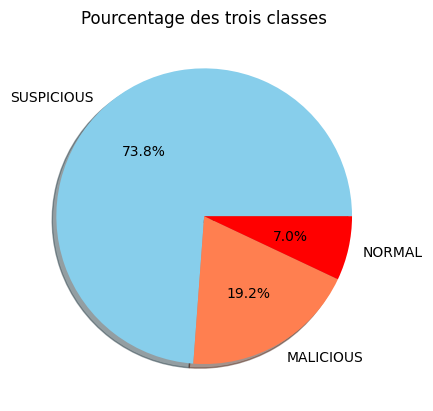

triage_label
NORMAL        4948
SUSPICIOUS    1284
MALICIOUS      470
Name: count, dtype: int64


In [6]:
# Pourcentage des trois classes

df["triage_label"].value_counts().plot.pie(autopct="%1.1f%%", labels=labels, colors=["skyblue","coral", "red"],shadow=True)
plt.title("Pourcentage des trois classes")
plt.ylabel("")
plt.show()

print(df['triage_label'].value_counts())

In [7]:
df["source"].unique()

array(['authentication_logs', 'edr_alerts'], dtype=object)

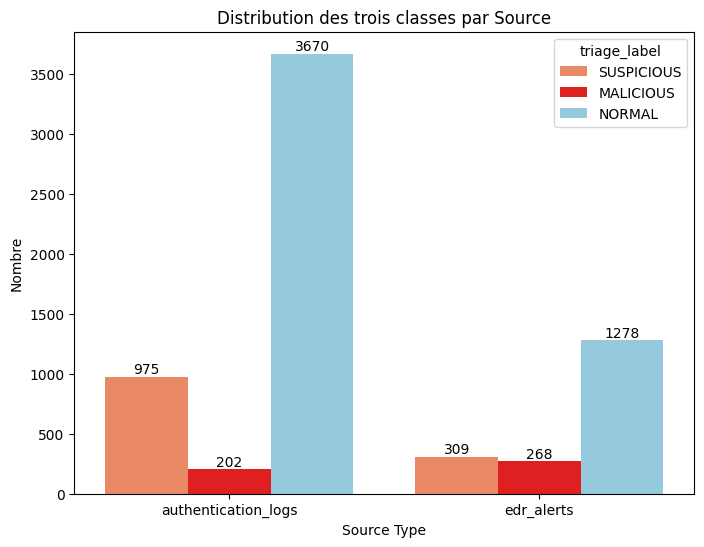

In [8]:
# Distribution par Source
plt.figure(figsize=(8,6))

ax = sns.countplot(x='source', hue='triage_label', data=df,
                   order=df['source'].value_counts(ascending=False).index,
                   palette=["coral","red" ,"skyblue"])

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution des trois classes par Source')
plt.ylabel('Nombre')
plt.xlabel('Source Type')
plt.show()

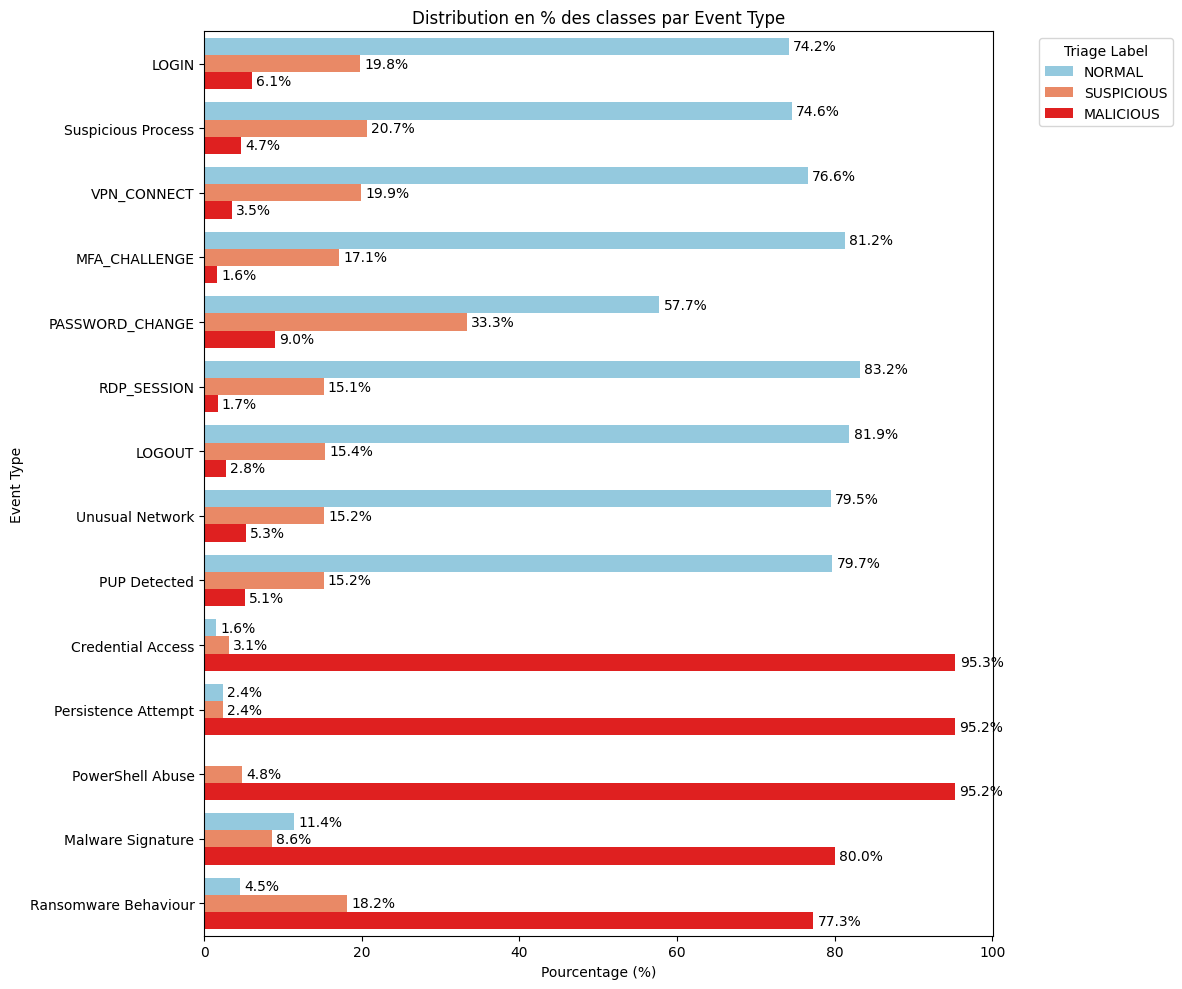

In [9]:
# Distribution par Event type
plt.figure(figsize=(12, 10))

# Calcul des pourcentages par type d'événement
counts = df.groupby(['event_type', 'triage_label']).size().reset_index(name='count')
totals = counts.groupby('event_type')['count'].transform('sum')
counts['percentage'] = (counts['count'] / totals) * 100

# Définition de l'ordre (basé sur la fréquence totale des événements)
event_order = df['event_type'].value_counts().index

ax = sns.barplot(x='percentage', y='event_type', hue='triage_label', data=counts,
                   order=event_order,
                   hue_order=['NORMAL', 'SUSPICIOUS', 'MALICIOUS'],
                   palette=["skyblue","coral","red"])

# Ajout des étiquettes de pourcentage sur les barres
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title('Distribution en % des classes par Event Type')
plt.xlabel('Pourcentage (%)')
plt.ylabel('Event Type')
plt.legend(title='Triage Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

 Après vérification, le jeu de données présente un fort déséquilibre de classes, caractérisé par une écrasante majorité d'événements normaux. Si le modèle de Machine Learning se contente de prédire systématiquement cette classe majoritaire, il échouera à détecter les vrais positifs (les activités suspectes ou malveillantes). Pour la surveillance de sécurité, les conséquences d'un tel biais seraient critiques, car de véritables cyberattaques passeraient totalement inaperçues au travers de nos défenses

## 3. Colonnes utilisables et fuite de cible



Les colonnes à exclure:
 * **triage_label** - La Variable Cible (Target) :  Il s'agit de la variable cible que le modèle doit apprendre à prédire. Elle représente la conclusion finale portée sur l'événement après une investigation complète de l'incident. Elle est par définition inconnue au moment où l'événement arrive.
 * **label** : Cette colonne contient la décision historique rendue par l'analyste lors du traitement de l'alerte à l'époque. L'utiliser pour entraîner le modèle provoquerait un surapprentissage.
 * **event_id** : C'est une clé technique unique de haute cardinalité sans aucun pouvoir statistique ou prédictif pour un algorithme.
 * **user_id**, **device_id** et **src_ip** : exclut sur sa forme brute. Motif : Ces champs possèdent une cardinalité trop élevée (chaque utilisateur/machine a un identifiant unique), ce qui entraînerait un surapprentissage massif. Toutefois, ils sont disponibles à T=0 et doivent impérativement être utilisés pour le Feature Engineering glissant (ex. : nombre d'échecs de connexion récents pour un utilisateur, volume d'activité récent d'une machine).




## 4. Feature engineering


In [10]:
df_feature = df.copy()

In [11]:
# Feature Engineering caractéristiques temporelles (heure, nuit/jour, jour de semaine)

df_feature["datetime"] = pd.to_datetime(df_feature["timestamp"], errors="coerce")

#  date
df_feature["date"] = df_feature["datetime"].dt.date

#  Heure brute (0-23)
df_feature["hour"] = df_feature["datetime"].dt.hour.fillna(-1).astype(int)

# Indicateur nuit (1 si entre 20h00 et 05h59, 0 sinon, -1 si heure invalide)
df_feature["is_night"] = df_feature["hour"].apply(lambda h: -1 if h == -1 else (1 if (h >= 20 or h < 6) else 0))

# . Indicateur jour (1 si entre 06h00 et 19h59, 0 sinon, -1 si heure invalide)
df_feature["is_day"] = df_feature["hour"].apply(lambda h: -1 if h == -1 else (1 if (6 <= h < 20) else 0))

# . Jour de la semaine (0 = Lundi, 6 = Dimanche)
df_feature["day_of_week"] = df_feature["datetime"].dt.dayofweek.fillna(-1).astype(int)

# Supprimer la colonne datetime intermédiaire
#df_feature.drop(columns=["datetime"], inplace=True)

# Réorganiser l'ordre pour inclure les nouvelles caractéristiques juste après la source/event_id ou à la fin
# Mettons-les juste après le timestamp pour la clarté
cols = list(df_feature.columns)
# On va repositionner les nouvelles colonnes
new_cols = ["hour", "is_night", "is_day", "day_of_week","date"]
for c in new_cols:
      if c in cols:
            cols.remove(c)
# Insérer après 'timestamp'
idx = cols.index("timestamp") + 1
for i, c in enumerate(new_cols):
     cols.insert(idx + i, c)

df_feature = df_feature[cols]

In [12]:
df_feature.head()

,timestamp,hour,is_night,is_day,day_of_week,date,source,event_id,user_id,device_id,...,privileged_account,hostname,asset_type,asset_owner,asset_criticality,user_known,device_known,label,triage_label,datetime
0,2026-03-02 01:31:00,1,1,0,0,2026-03-02,authentication_logs,AUTH003692,U0190,D0154,...,YES,PHF-LT-0154,Mobile,Finance,HIGH,True,True,UNLABELED,SUSPICIOUS,2026-03-02 01:31:00
1,2026-03-02 01:41:00,1,1,0,0,2026-03-02,authentication_logs,AUTH000733,U0008,D0029,...,NO,PHF-WS-0029,Server,IT,CRITICAL,True,True,UNLABELED,MALICIOUS,2026-03-02 01:41:00
2,2026-03-02 01:53:00,1,1,0,0,2026-03-02,authentication_logs,AUTH000859,U0343,D0025,...,NO,PHF-WS-0025,Laptop,RH,LOW,True,True,UNLABELED,NORMAL,2026-03-02 01:53:00
3,2026-03-02 02:32:15,2,1,0,0,2026-03-02,authentication_logs,AUTH002474,U0202,D0053,...,NO,PHF-SRV-0053,Server,Regions,MEDIUM,True,True,UNLABELED,SUSPICIOUS,2026-03-02 02:32:15
4,2026-03-02 02:50:24,2,1,0,0,2026-03-02,authentication_logs,AUTH002027,U0226,D0041,...,NO,PHF-SRV-0041,VM,Direction,CRITICAL,True,True,UNLABELED,SUSPICIOUS,2026-03-02 02:50:24


In [14]:
# Signal : échecs récents du même utilisateur dans les 20 minutes précédentes
auth_failed = (
    (df_feature["source"] == "authentication_logs") &
    (df_feature["authentication_result"] == "FAILED") &
    (df_feature["user_id"] != "UNKNOWN")
)
failed = df_feature.loc[auth_failed, ["datetime", "user_id"]].copy()

recent_failed_user = []
for _, row in df_feature.iterrows():
    t, uid = row["datetime"], row["user_id"]
    if pd.isna(t) or uid == "UNKNOWN":
        recent_failed_user.append(0)
        continue
    m = (failed["user_id"] == uid) & (failed["datetime"] < t) & (failed["datetime"] >= t - pd.Timedelta(minutes=20))
    recent_failed_user.append(int(m.sum()))
df_feature["recent_failed_user_20m"] = recent_failed_user

In [13]:
df_feature.head()

,timestamp,hour,is_night,is_day,day_of_week,date,source,event_id,user_id,device_id,...,privileged_account,hostname,asset_type,asset_owner,asset_criticality,user_known,device_known,label,triage_label,datetime
0,2026-03-02 01:31:00,1,1,0,0,2026-03-02,authentication_logs,AUTH003692,U0190,D0154,...,YES,PHF-LT-0154,Mobile,Finance,HIGH,True,True,UNLABELED,SUSPICIOUS,2026-03-02 01:31:00
1,2026-03-02 01:41:00,1,1,0,0,2026-03-02,authentication_logs,AUTH000733,U0008,D0029,...,NO,PHF-WS-0029,Server,IT,CRITICAL,True,True,UNLABELED,MALICIOUS,2026-03-02 01:41:00
2,2026-03-02 01:53:00,1,1,0,0,2026-03-02,authentication_logs,AUTH000859,U0343,D0025,...,NO,PHF-WS-0025,Laptop,RH,LOW,True,True,UNLABELED,NORMAL,2026-03-02 01:53:00
3,2026-03-02 02:32:15,2,1,0,0,2026-03-02,authentication_logs,AUTH002474,U0202,D0053,...,NO,PHF-SRV-0053,Server,Regions,MEDIUM,True,True,UNLABELED,SUSPICIOUS,2026-03-02 02:32:15
4,2026-03-02 02:50:24,2,1,0,0,2026-03-02,authentication_logs,AUTH002027,U0226,D0041,...,NO,PHF-SRV-0041,VM,Direction,CRITICAL,True,True,UNLABELED,SUSPICIOUS,2026-03-02 02:50:24


In [15]:
# Succès après une série d'échecs : seuil opérationnel choisi = au moins 3 échecs récents
df_feature["success_after_failures"] = (
    (df_feature["authentication_result"] == "SUCCESS") &
    (df_feature["recent_failed_user_20m"] >= 3)
).astype(int)


In [16]:
# Croisement privilège x criticité
df_feature["privileged_on_critical_asset"] = (
    (df_feature["privileged_account"] == "YES") &
    (df_feature["asset_criticality"].isin(["HIGH", "CRITICAL"]))
).astype(int)

In [17]:
# Volume d'activité dans les 20 minutes précédentes

recent_activity_user = []
recent_activity_device = []

for _, row in df_feature.iterrows():

    t = row["datetime"]
    uid = row["user_id"]
    device = row["device_id"]

    # Activité utilisateur
    if pd.isna(t) or uid == "UNKNOWN":
        recent_activity_user.append(0)
    else:
        mask_user = (
            (df_feature["user_id"] == uid) &
            (df_feature["datetime"] < t) &
            (df_feature["datetime"] >= t - pd.Timedelta(minutes=20))
        )

        recent_activity_user.append(int(mask_user.sum()))

    # Activité machine
    if pd.isna(t) or device == "UNKNOWN":
        recent_activity_device.append(0)
    else:
        mask_device = (
            (df_feature["device_id"] == device) &
            (df_feature["datetime"] < t) &
            (df_feature["datetime"] >= t - pd.Timedelta(minutes=20))
        )

        recent_activity_device.append(int(mask_device.sum()))


# Création des features
df_feature["user_activity_20m"] = recent_activity_user
df_feature["device_activity_20m"] = recent_activity_device

In [18]:
# Détection d'une localisation inhabituelle pour l'utilisateur

unusual_location = []

# Dictionnaire contenant les localisations déjà observées
user_locations = {}

for _, row in df_feature.iterrows():

    uid = row["user_id"]
    location = row["location"]

    # Cas non exploitables
    if uid == "UNKNOWN" or pd.isna(location) or location == "UNKNOWN":
        unusual_location.append(0)
        continue

    # Premier événement connu de l'utilisateur :
    # pas assez d'historique pour conclure
    if uid not in user_locations:
        unusual_location.append(0)
        user_locations[uid] = {location}
        continue

    # Vérifier si la localisation a déjà été observée
    if location in user_locations[uid]:
        unusual_location.append(0)
    else:
        unusual_location.append(1)

    # Ajouter la localisation à l'historique
    user_locations[uid].add(location)


df_feature["unusual_location"] = unusual_location

In [46]:
# 1 = compte inactif, 0 = compte actif
df_feature["is_inactive_account"] = (
    df_feature["employment_status"] == "INACTIVE"
).astype(int)

In [47]:
df_feature.head()

,timestamp,hour,is_night,is_day,day_of_week,date,source,event_id,user_id,device_id,...,label,triage_label,datetime,recent_failed_user_20m,success_after_failures,privileged_on_critical_asset,user_activity_20m,device_activity_20m,unusual_location,is_inactive_account
0,2026-03-02 01:31:00,1,1,0,0,2026-03-02,authentication_logs,AUTH003692,U0190,D0154,...,UNLABELED,SUSPICIOUS,2026-03-02 01:31:00,0,0,1,0,0,0,0
1,2026-03-02 01:41:00,1,1,0,0,2026-03-02,authentication_logs,AUTH000733,U0008,D0029,...,UNLABELED,MALICIOUS,2026-03-02 01:41:00,0,0,0,0,0,0,0
2,2026-03-02 01:53:00,1,1,0,0,2026-03-02,authentication_logs,AUTH000859,U0343,D0025,...,UNLABELED,NORMAL,2026-03-02 01:53:00,0,0,0,0,0,0,0
3,2026-03-02 02:32:15,2,1,0,0,2026-03-02,authentication_logs,AUTH002474,U0202,D0053,...,UNLABELED,SUSPICIOUS,2026-03-02 02:32:15,0,0,0,0,0,0,0
4,2026-03-02 02:50:24,2,1,0,0,2026-03-02,authentication_logs,AUTH002027,U0226,D0041,...,UNLABELED,SUSPICIOUS,2026-03-02 02:50:24,0,0,0,0,0,0,0


## 5. Séparation train / test


In [48]:
# Exclusion des colonnes comme indiqué dans l'étape 3
# identifiants quasi uniques / cible / historique post-investigation / timestamp brut

exclude = ["triage_label", "label", "event_id", "timestamp", "datetime","user_id","device_id","hostname","src_ip","asset_owner"]
features = [c for c in df_feature.columns if c not in exclude]


In [80]:
#  train_test_split stratifié
X = df_feature[features]
y = df_feature["triage_label"]


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

## 6. Preprocessing

In [79]:
#  ColumnTransformer + Pipeline

num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])


In [52]:
print(f"Nombre de colonnes numériques: {len(num_cols)}")
print(num_cols)

Nombre de colonnes numériques: 11
['hour', 'is_night', 'is_day', 'day_of_week', 'recent_failed_user_20m', 'success_after_failures', 'privileged_on_critical_asset', 'user_activity_20m', 'device_activity_20m', 'unusual_location', 'is_inactive_account']


In [53]:
len(cat_cols)

16

## 7. Baseline


In [78]:
#  baseline

# Création du pipeline
baseline = Pipeline([
    ("preprocess", preprocess),
    ("model", DummyClassifier(
         strategy="most_frequent",
    ))
])


baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

In [55]:
# Évaluation de la baseline
print("=== BASELINE ===")

print("Accuracy :", round(accuracy_score(y_test, y_pred_baseline), 3))
print("F1 Score:", round(f1_score(y_test, y_pred_baseline,average="macro"), 3))

print("\nClassification report :")
print(classification_report(y_test, y_pred_baseline, zero_division=0))

=== BASELINE ===
Accuracy : 0.738
F1 Score: 0.283

Classification report :
              precision    recall  f1-score   support

   MALICIOUS       0.00      0.00      0.00       118
      NORMAL       0.74      1.00      0.85      1237
  SUSPICIOUS       0.00      0.00      0.00       321

    accuracy                           0.74      1676
   macro avg       0.25      0.33      0.28      1676
weighted avg       0.54      0.74      0.63      1676



## 8. Entraînement  modèles


In [76]:
#  modèle 1

# Modèle de regression logistique
log_reg = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])



# Entraînement du modèle
log_reg.fit(X_train, y_train)

# Prédictions
y_pred_log = log_reg.predict(X_test)



In [77]:
#  modèle 2

# Modèle de random forest
rf_model = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])


# Entraînement du modèle
rf_model.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf_model.predict(X_test)




## 9. Évaluation


=== LOGISTIC REGRESSION ===
Accuracy : 0.755
Macro F1 : 0.697

Classification report :
              precision    recall  f1-score   support

   MALICIOUS       0.64      0.76      0.70       118
      NORMAL       0.96      0.75      0.84      1237
  SUSPICIOUS       0.43      0.76      0.55       321

    accuracy                           0.75      1676
   macro avg       0.68      0.76      0.70      1676
weighted avg       0.84      0.75      0.78      1676



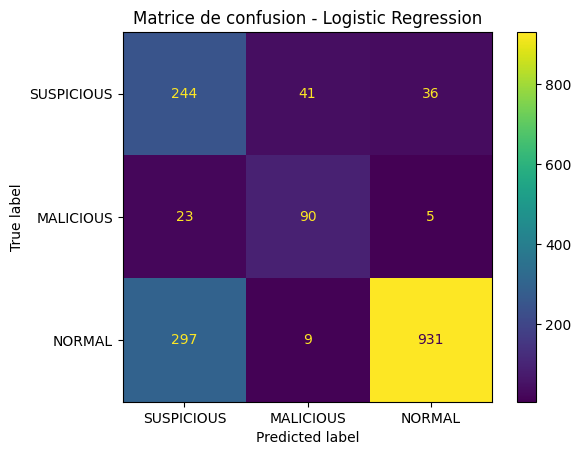

In [74]:
# évaluation comparée
# Résultats
print("=== LOGISTIC REGRESSION ===")

print("Accuracy :", round(accuracy_score(y_test, y_pred_log), 3))
print("Macro F1 :", round(f1_score(y_test, y_pred_log, average="macro"), 3))

print("\nClassification report :")
print(classification_report(y_test, y_pred_log, zero_division=0))


# Matrice de confusion
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    labels=labels
)

plt.title("Matrice de confusion - Logistic Regression")
plt.grid(False)
plt.show()

=== LOGISTIC REGRESSION ===
Accuracy : 0.755
Macro F1 : 0.697

Classification report :
              precision    recall  f1-score   support

   MALICIOUS       0.64      0.76      0.70       118
      NORMAL       0.96      0.75      0.84      1237
  SUSPICIOUS       0.43      0.76      0.55       321

    accuracy                           0.75      1676
   macro avg       0.68      0.76      0.70      1676
weighted avg       0.84      0.75      0.78      1676



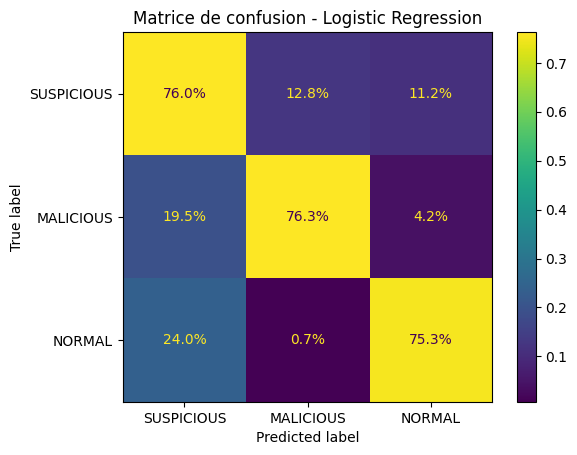

In [75]:
#  évaluation comparée
# Résultats
print("=== LOGISTIC REGRESSION ===")

print("Accuracy :", round(accuracy_score(y_test, y_pred_log), 3))
print("Macro F1 :", round(f1_score(y_test, y_pred_log, average="macro"), 3))

print("\nClassification report :")
print(classification_report(y_test, y_pred_log, zero_division=0))


# Matrice de confusion
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    labels=labels,
    normalize="true",
    values_format=".1%"
)

plt.title("Matrice de confusion - Logistic Regression")
plt.grid(False)
plt.show()

La régression logistique détecte correctement 91 des 118 événements MALICIOUS. Parmi les 27 événements MALICIOUS mal classés, 22 sont classés SUSPICIOUS et restent donc susceptibles de faire l'objet d'une investigation humaine. Le principal risque opérationnel concerne les 5 événements MALICIOUS classés NORMAL, qui pourraient ne pas être investigués. Le modèle génère également une charge supplémentaire pour le SOC, avec 296 événements NORMAL classés SUSPICIOUS. Le modèle présente donc un compromis entre détection des menaces et augmentation du volume d'investigations.

=== RANDOM FOREST ===
Accuracy : 0.837
F1 : 0.712

Classification report :
              precision    recall  f1-score   support

   MALICIOUS       0.77      0.62      0.69       118
      NORMAL       0.88      0.95      0.91      1237
  SUSPICIOUS       0.63      0.46      0.54       321

    accuracy                           0.84      1676
   macro avg       0.76      0.68      0.71      1676
weighted avg       0.82      0.84      0.83      1676



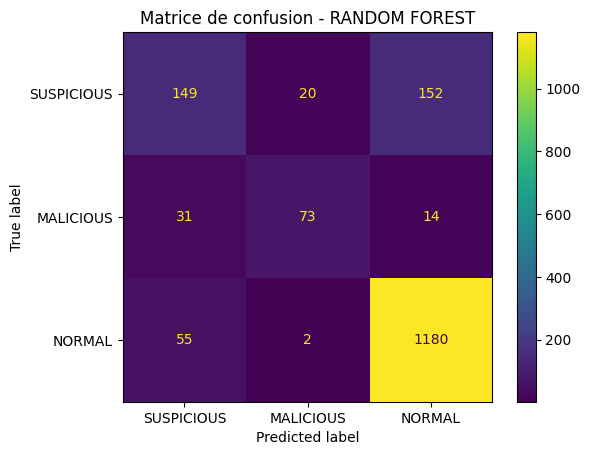

In [63]:
# Résultats
print("=== RANDOM FOREST ===")

print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 3))
print("F1 :", round(f1_score(y_test, y_pred_rf, average="macro"), 3))

print("\nClassification report :")
print(classification_report(y_test, y_pred_rf, zero_division=0))


# Matrice de confusion
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    labels=labels
)

plt.title("Matrice de confusion - RANDOM FOREST")
plt.grid(False)
plt.show()

=== RANDOM FOREST ===
Accuracy : 0.837
F1 : 0.712

Classification report :
              precision    recall  f1-score   support

   MALICIOUS       0.77      0.62      0.69       118
      NORMAL       0.88      0.95      0.91      1237
  SUSPICIOUS       0.63      0.46      0.54       321

    accuracy                           0.84      1676
   macro avg       0.76      0.68      0.71      1676
weighted avg       0.82      0.84      0.83      1676



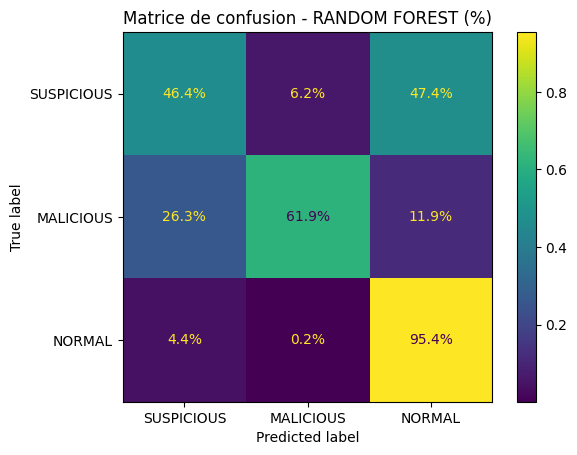

In [61]:
# Résultats
print("=== RANDOM FOREST ===")

print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 3))
print("F1 :", round(f1_score(y_test, y_pred_rf, average="macro"), 3))

print("\nClassification report :")
print(classification_report(y_test, y_pred_rf, zero_division=0))


# Matrice de confusion en pourcentage
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    labels=labels,
    normalize="true",
    values_format=".1%"
)

plt.title("Matrice de confusion - RANDOM FOREST (%)")
plt.grid(False)
plt.show()

Random Forest est meilleure pour reconnaître les événements normaux, mais Logistic Regression est meilleure pour ne pas laisser passer les événements malveillants.

La Random Forest obtient une accuracy de 84 % et un macro F1 de 0,70. Elle reconnaît particulièrement bien la classe NORMAL avec un recall de 96 %. Cependant, son recall pour la classe MALICIOUS n'est que de 57 %. Sur 118 événements réellement malveillants, 67 sont correctement classés MALICIOUS, 33 sont classés SUSPICIOUS et 18 sont classés NORMAL. Ces 18 faux négatifs représentent un risque important pour le SOC car ils pourraient ne pas être investigués. En comparaison, la régression logistique ne classe que 5 événements MALICIOUS comme NORMAL. Malgré une performance globale plus faible, la régression logistique apparaît donc plus adaptée à l'objectif métier de détection des incidents.

## 10. Analyse des erreurs et arbitrage métier

 Un faux négatif est plus critique qu'un faux positif.
Un faux positif augmente la charge de travail des analystes, tandis qu'un événement MALICIOUS classé NORMAL risque de ne jamais être investigué.
Il faut privilieger un modèle capable de limiter les faux négatifs, même au prix d'une augmentation des faux positifs.



## 11. Choix du modèle final

 Sur les deux modèles testés, la régression logistique présente un compromis intéressant : elle génère davantage d'alertes à examiner, mais réduit le nombre d'événements MALICIOUS classés NORMAL par rapport à la Random Forest (5 contre 18). Ce choix privilégie donc la capacité de détection et la sécurité plutôt que la seule accuracy.

## 12. Impact projet


Réduire les faux positifs sans augmenter fortement le nombre d'événements MALICIOUS classés NORMAL.

Faire une analyse des faux positifs afin d'identifier les événements que le modèle confond avec SUSPICIOUS.

- analyser les caractéristiques des faux positifs ;
- identifier les types d'événements générant le plus de faux positifs ;
- vérifier certaines features comme unusual_location, user_activity_20m ou recent_failed_user_20m ;
- ajuster le modèle ou ses seuils si nécessaire ;
- comparer à nouveau le nombre de faux positifs et le nombre de faux négatifs MALICIOUS.


Impact : élevé.

Criticité : élevée.

Responsable : Data Scientist avec validation du responsable SOC.

Arbitrage : le déploiement du prototype est temporairement retardé afin d'analyser les 35 % de faux positifs et d'ajuster le modèle.

L'objectif est de réduire la charge d'investigation du SOC sans dégrader significativement le recall de la classe MALICIOUS.

Le backlog est complété par une analyse des faux positifs, une optimisation du modèle et une nouvelle validation métier.

Le Risk Register est mis à jour avec les risques de surcharge des analystes, d'alert fatigue et d'augmentation des faux négatifs après optimisation.

=== RANDOM FOREST ===
Accuracy : 0.786
F1 : 0.711

Classification report :
              precision    recall  f1-score   support

   MALICIOUS       0.70      0.69      0.70       118
      NORMAL       0.94      0.82      0.87      1237
  SUSPICIOUS       0.47      0.70      0.56       321

    accuracy                           0.79      1676
   macro avg       0.70      0.74      0.71      1676
weighted avg       0.83      0.79      0.80      1676



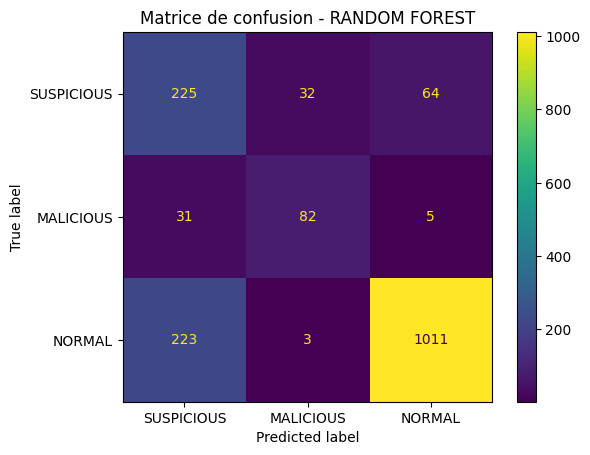

In [73]:
rf_model = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt"
    ))
])


# Entraînement du modèle
rf_model.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf_model.predict(X_test)


# Résultats
print("=== RANDOM FOREST ===")

print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 3))
print("F1 :", round(f1_score(y_test, y_pred_rf, average="macro"), 3))

print("\nClassification report :")
print(classification_report(y_test, y_pred_rf, zero_division=0))


# Matrice de confusion
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    labels=labels
)

plt.title("Matrice de confusion - RANDOM FOREST")
plt.grid(False)
plt.show()